# Data Exploration

In this notebook, I explore the German Credit dataset to understand its structure, the target variable, and the math patterns in the data befire preprocessing and modeling.

## Importing libraries

First, I import the libraries that will be used to load, explore and visualize the data.

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#from ucimlrepo import fetch_ucirepo

## Loading the dataset

The original plan was to load the dataset from the UCI repository, but the connection failed in the current environment. To continue the project in a stable way, I load the German Credit dataset from the public online source using pandas.

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"

df = pd.read_csv(url)
df.head()

,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1.1
0,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
2,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
3,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
4,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1


## Assigning Column Names


The dataset does not include column headers by default. Therefore, we manually define the column names based on the dataset description. This step is essential because it improves the readability of the data and allows for a clearer interpretation during the exploratory data analysis.

In [5]:
df.columns = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
2,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
3,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
4,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1


The dataset now contains clearly labeled columns, making it easier to understand the different features. Each column represents a specific attribute related to the credit applicant, while the "target" column indicates the credit risk.

## Description of Categorical Variables

Several categorical variables in the dataset use coded values (e.g., A11, A12, etc.). These codes correspond to specific categories defined in the dataset documentation. Below is a description of the main categorical variables and their meanings.

Checking Account Status (`checking_account_status`)
- A11: balance < 0
- A12: 0 ≤ balance < 200
- A13: balance ≥ 200
- A14: no checking account

Credit History (`credit_history`)
- A30: no credits taken / all paid back
- A31: all credits paid back duly
- A32: existing credits paid back duly
- A33: delay in paying off credits
- A34: critical account

Purpose (`purpose`)
- A40: car (new)
- A41: car (used)
- A42: furniture/equipment
- A43: radio/television
- A44: domestic appliances
- A45: repairs
- A46: education
- A47: vacation
- A48: retraining
- A49: business
- A410: others

Savings Account (`savings_account`)
- A61: < 100
- A62: 100 ≤ savings < 500
- A63: 500 ≤ savings < 1000
- A64: ≥ 1000
- A65: unknown / no savings account

Employment Since (`employment_since`)
- A71: unemployed
- A72: < 1 year
- A73: 1 ≤ years < 4
- A74: 4 ≤ years < 7
- A75: ≥ 7 years

Personal Status and Sex (`personal_status_sex`)
- A91: male, divorced/separated
- A92: female, divorced/separated/married
- A93: male, single
- A94: male, married/widowed
- A95: female, single

Other Debtors (`other_debtors`)
- A101: none
- A102: co-applicant
- A103: guarantor

Property (`property`)
- A121: real estate
- A122: savings agreement / life insurance
- A123: car or other
- A124: unknown / no property

Other Installment Plans (`other_installment_plans`)
- A141: bank
- A142: stores
- A143: none

Housing (`housing`)
- A151: rent
- A152: own
- A153: for free

Job (`job`)
- A171: unemployed / unskilled (non-resident)
- A172: unskilled (resident)
- A173: skilled employee
- A174: highly skilled / self-employed / management

Telephone (`telephone`)
- A191: none
- A192: yes

Foreign Worker (`foreign_worker`)
- A201: yes
- A202: no

These coded values are kept in the dataset for analysis. They are transformed into numerical format during preprocessing using encoding techniques.

## Preview of the Dataset

After assigning column names, we examine the first few rows of the dataset. This helps us understand how the data is organized, the types of variables present, and whether the column names have been correctly applied.

In [6]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
df.info()

Shape: (999, 21)

Columns:
 ['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex', 'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'target']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  999 non-null    str  
 1   duration_months          999 non-null    int64
 2   credit_history           999 non-null    str  
 3   purpose                  999 non-null    str  
 4   credit_amount            999 non-null    int64
 5   savings_account          999 non-null    str  
 6   employment_since         999 non-null    str  
 7   installment_rate         999 non-null    int6

The dataset contains 999 observations and 21 variables, including the target variable.

It includes both numerical and categorical variables:
- 8 numerical variables
- 13 categorical variables

There are no missing values in the dataset, which simplifies the preprocessing step.

However, the dataset was initially loaded with incorrect column names. This issue was fixed by explicitly defining the column names during loading.

## Duplicated rows

I also check if there are duplicated rows in the dataset.

In [7]:
df.duplicated().sum()

np.int64(0)

This helps detect possible quality issues that could affect the analysis. In our dataset we don't have this problem.

## Target variable analysis

We analyze the distribution of the target variable to understand the balance between classes. This is important for classification problems, as imbalanced data can affect model performance.

In [8]:
target_col = "target"

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

target
1    699
2    300
Name: count, dtype: int64
target
1    69.96997
2    30.03003
Name: proportion, dtype: float64


This shows the number of observations in each class and the percentage distribution of the target variable. We can see it in two different ways the first by counting and the second with percentage. It's clear that the first class is more than the double of the second class.

## Target distribution plot

To make the target distribution easier to interpret, I visualise it with a bar chart.

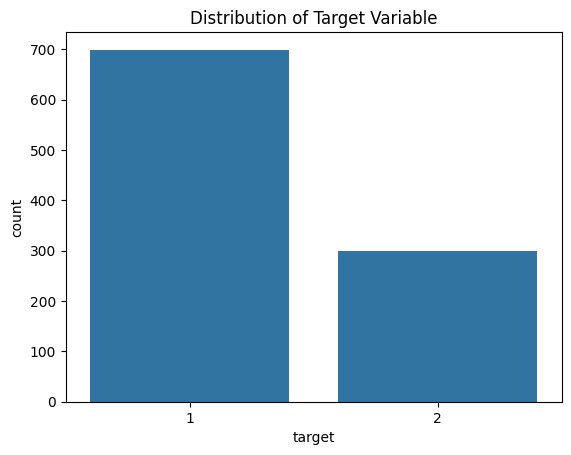

In [9]:
sns.countplot(data=df, x=target_col)
plt.title("Distribution of Target Variable")
plt.show()

The target variable is not evenly distributed. One class appears more frequently than the other, indicating a class imbalance. This is important because it may influence the performance of machine learning models and should be considered in later stages.

## Feature Types Identification

We separate the dataset into numerical and categorical variables, as each type requires different analysis and preprocessing techniques.

In [10]:
X = df.drop(columns=[target_col])
y = df[target_col]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'people_liable']
Categorical columns: ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


## Numerical Variables Analysis

We analyze the distribution of numerical variables to understand their range, spread, and potential outliers.

In [11]:
df[num_cols].describe()

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,20.917918,3273.362362,2.971972,2.843844,35.514515,1.406406,1.155155
std,12.055619,2823.365811,1.118802,1.103665,11.337487,0.577639,0.362234
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1368.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2320.000000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.500000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


The summary statistics give a first idea aboout the range, average and spread of the numerical variables.

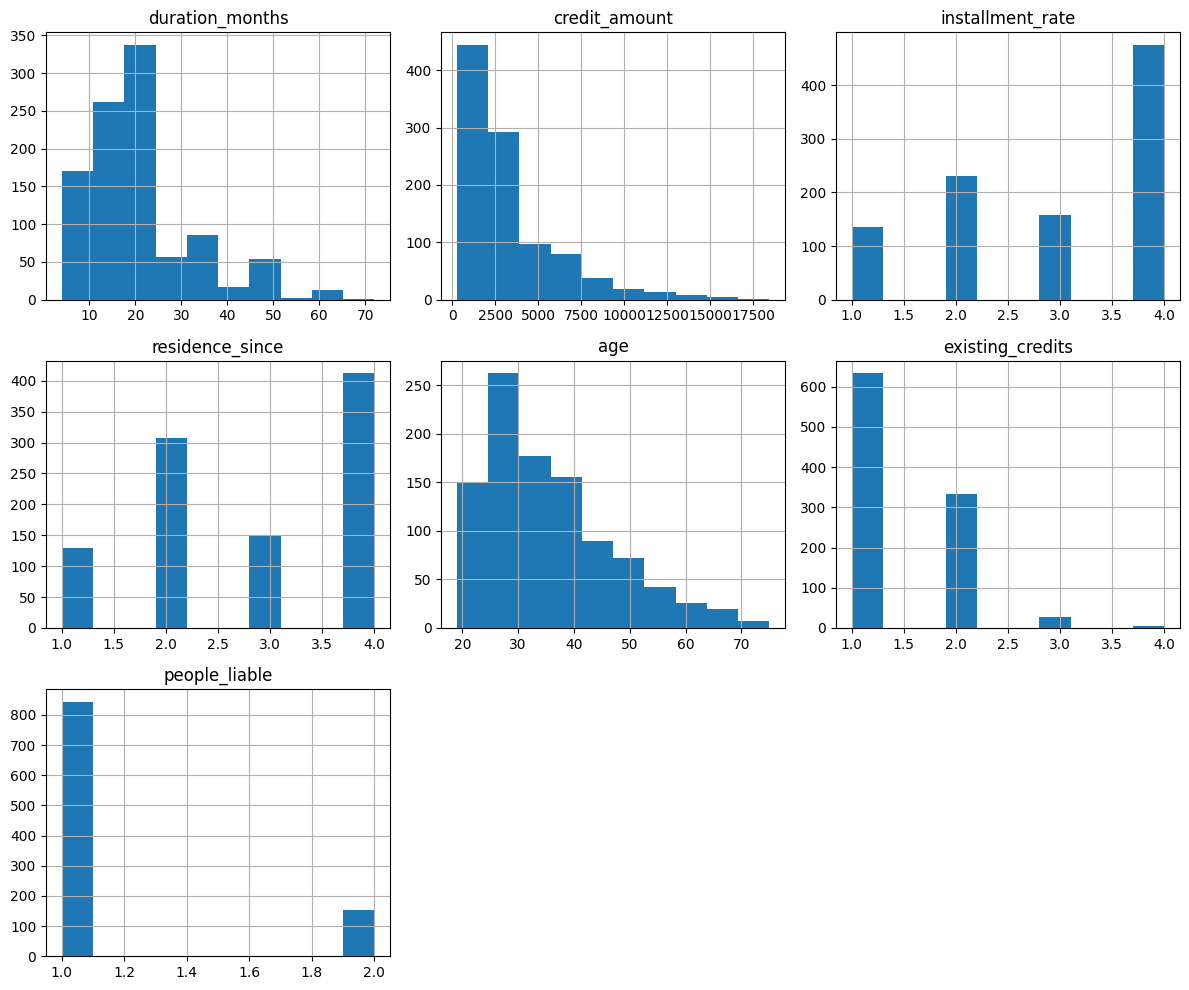

In [12]:
df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

The histograms help visualize the shape of each variable. Some variables may be more spread out than others and some may be skewed.

The numerical variables show different distributions. Some variables, such as "credit_amount", appear right-skewed, with a few higher values. Other variables, such as "installment_rate", "present_residence_since", and "dependents", take only a small number of discrete values.


## Boxplots of numerical variables

I now use boxplots to detect possible outliers and better understand the spread of the numerical variables.

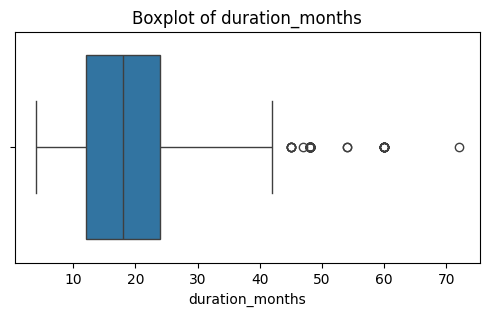

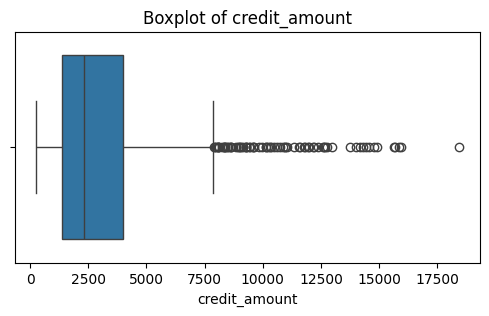

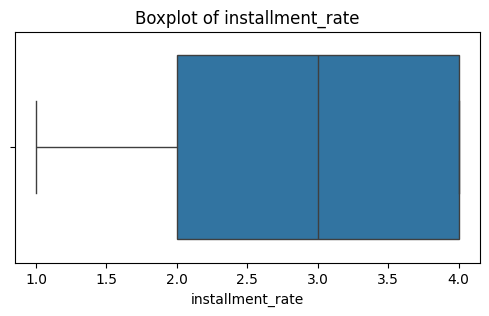

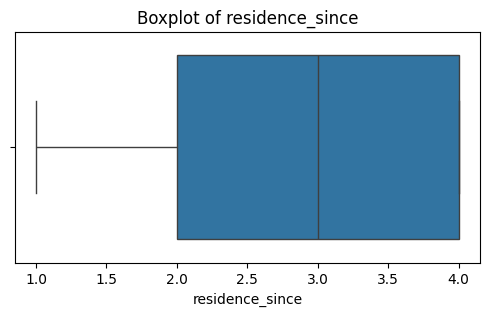

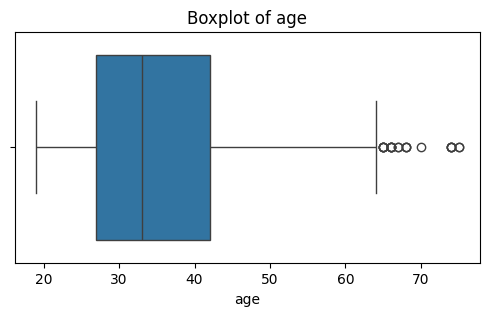

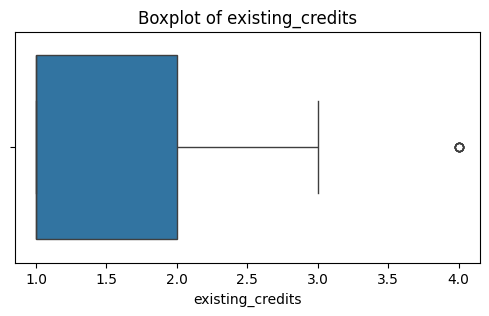

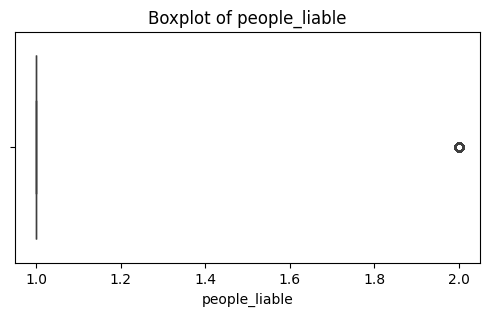

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


Most loan durations are concentrated around lower to medium values, especially between 12 and 24 months. There are also a few higher values above 40 months, which appear as outliers.

"credit_amount" is strongly right-skewed. Most credit amounts are relatively low, but there are many large values that appear as outliers. This suggests that a small number of clients requested much higher loan amounts than the rest.

"installment_rate" takes only a small number of discrete values, which is expected from the dataset description. No strong outliers appear in this variable.

"present_residence_since" also takes only a few discrete values. The variable does not show clear outliers and seems fairly well distributed across its categories.

Most clients are between 25 and 45 years old. There are also a few older clients that appear as outliers, which suggests a small number of observations at higher ages.

Most clients seem to have 1 or 2 existing credits at the bank. Higher values are rare and the value 4 appears as an outlier.

The "dependents" variable is highly concentrated at 1, while 2 appears only in a small number of cases. This means the variable has very limited variation.

## Univariate analysis of categorical variables

I now explore the categorical variables to understand the most commun categories in the dataset.

In [14]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for checking_account_status:
checking_account_status
A14    394
A11    273
A12    269
A13     63
Name: count, dtype: int64

Value counts for credit_history:
credit_history
A32    530
A34    292
A33     88
A31     49
A30     40
Name: count, dtype: int64

Value counts for purpose:
purpose
A43     279
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

Value counts for savings_account:
savings_account
A61    603
A65    182
A62    103
A63     63
A64     48
Name: count, dtype: int64

Value counts for employment_since:
employment_since
A73    339
A75    252
A74    174
A72    172
A71     62
Name: count, dtype: int64

Value counts for personal_status_sex:
personal_status_sex
A93    547
A92    310
A94     92
A91     50
Name: count, dtype: int64

Value counts for other_debtors:
other_debtors
A101    906
A103     52
A102     41
Name: count, dtype: int64

Value counts for property:
property
A123    332

The value counts show that the categorical variables are not evenly distributed across categories. In most features, one or two categories are much more frequent than the others.

For example, in `checking_account_status`, category A14 is the most common, while A13 is much less represented. Similarly, in `credit_history`, category A32 dominates the distribution, whereas A30 and A31 appear much less often. This pattern is also visible in other categorical variables such as `foreign_worker`, where one category is overwhelmingly more frequent than the other.

Overall, this indicates that the dataset contains imbalanced categorical distributions. These dominant categories may have a stronger influence during modeling, while rare categories may provide less information or require special attention during preprocessing.

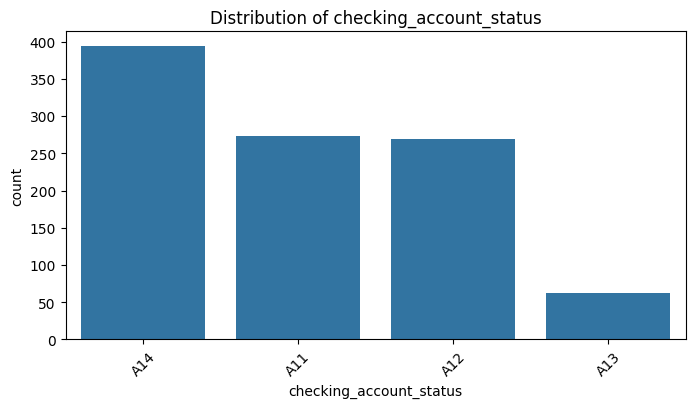

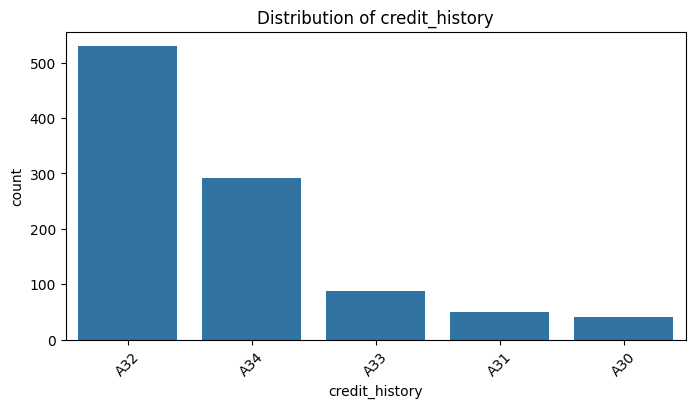

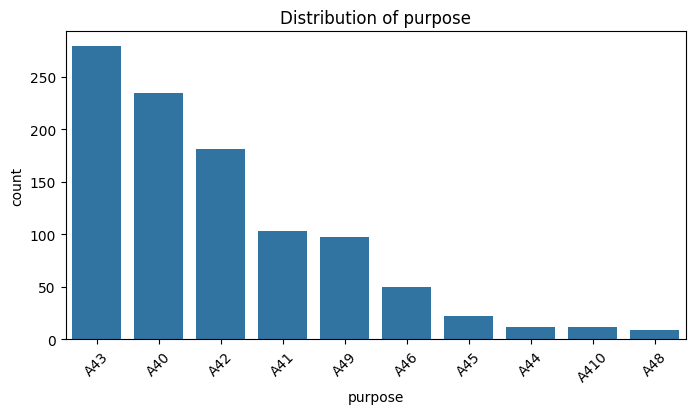

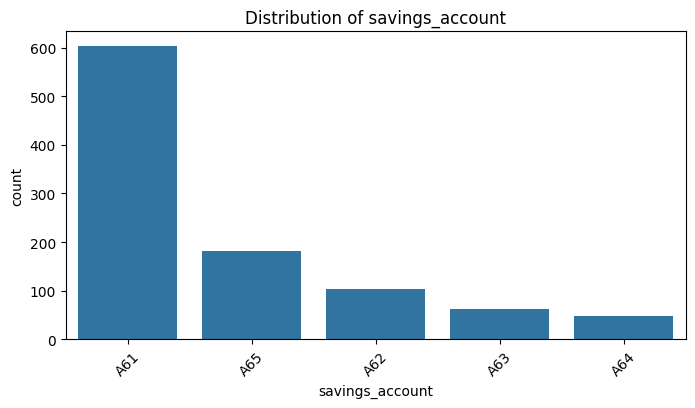

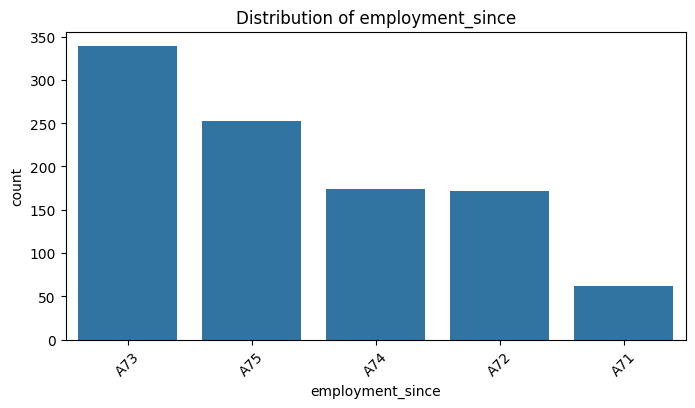

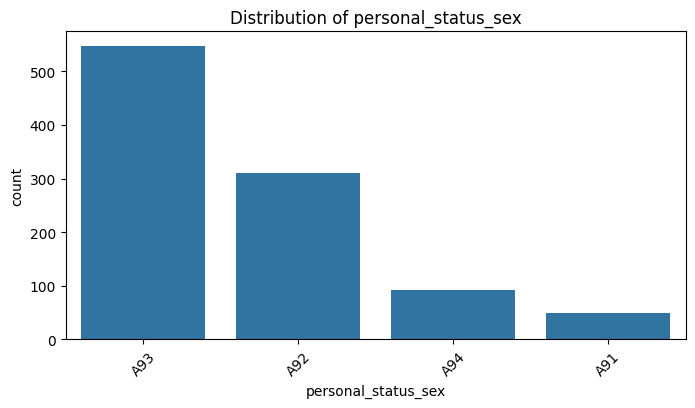

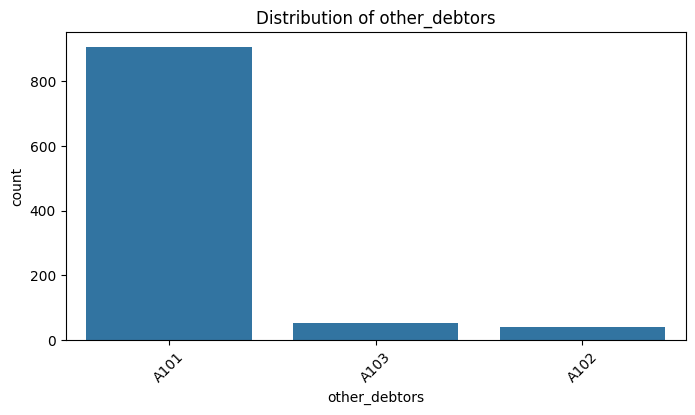

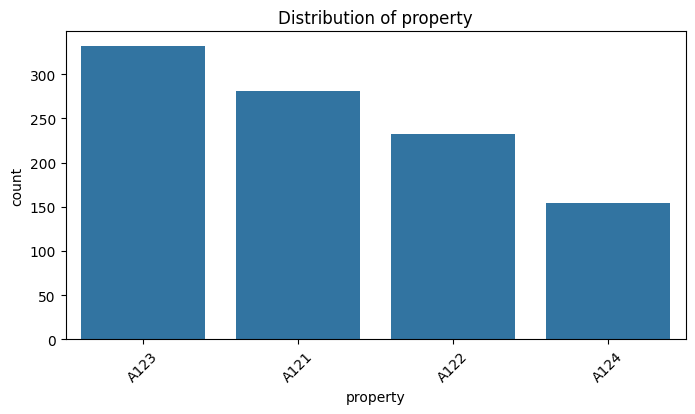

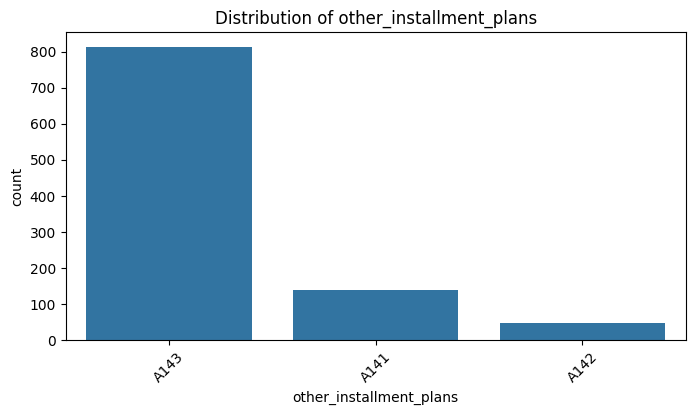

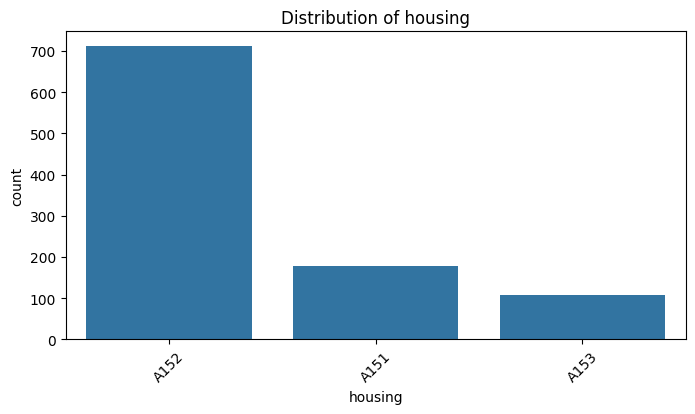

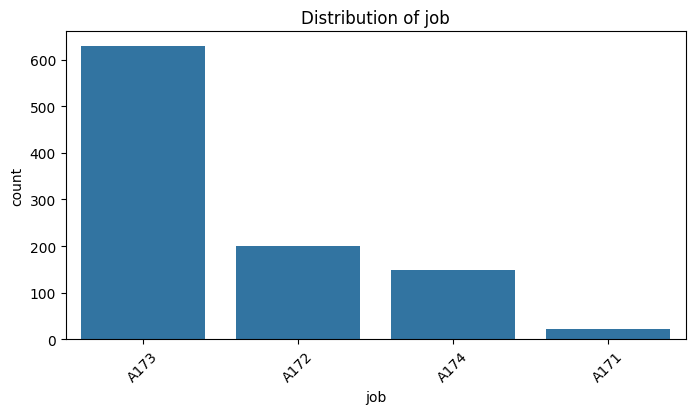

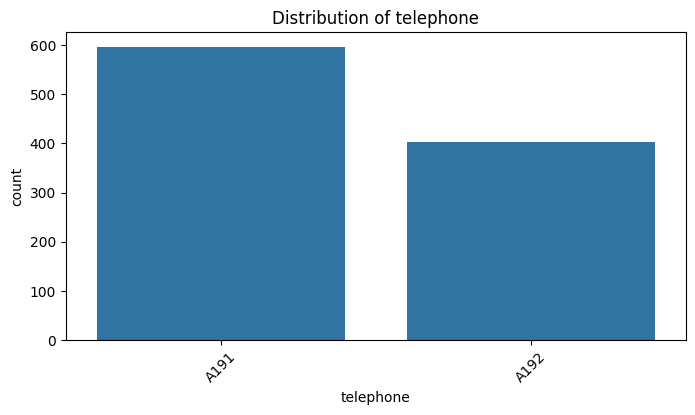

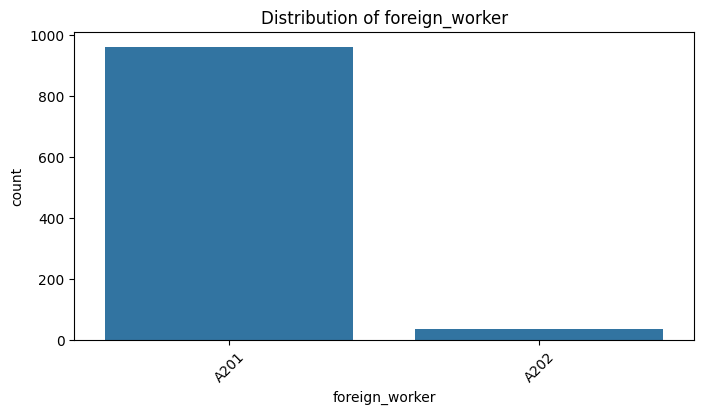

In [15]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

The categorical variables are unevenly distributed, with some categories appearing more frequently than others. This imbalance may influence the model and should be considered during preprocessing.

## Numerical variables vs target

I now compare the numerical variables across the target classes to see whether some variables behave differently depending on credit risk.

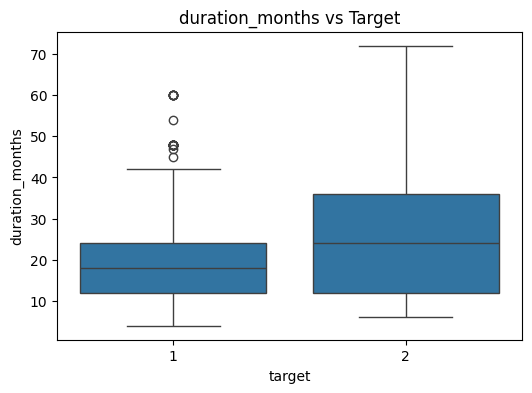

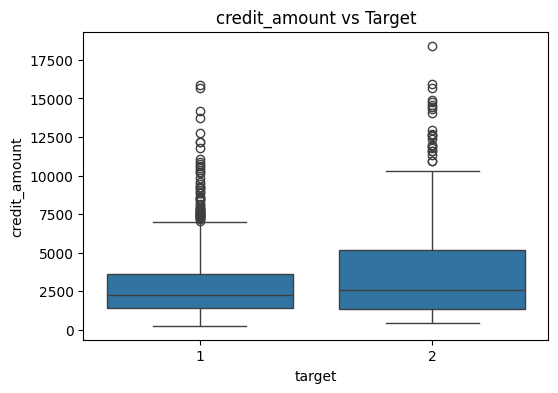

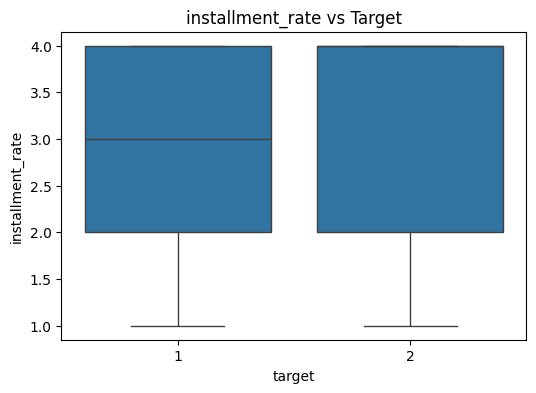

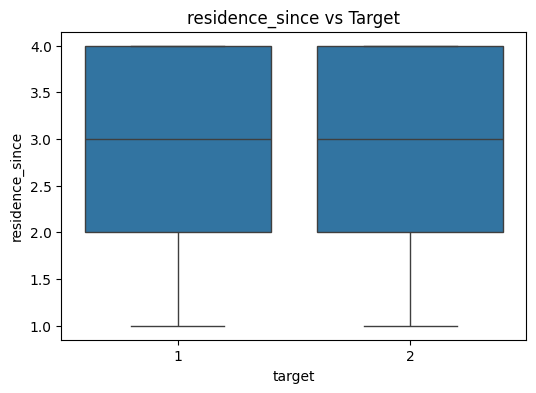

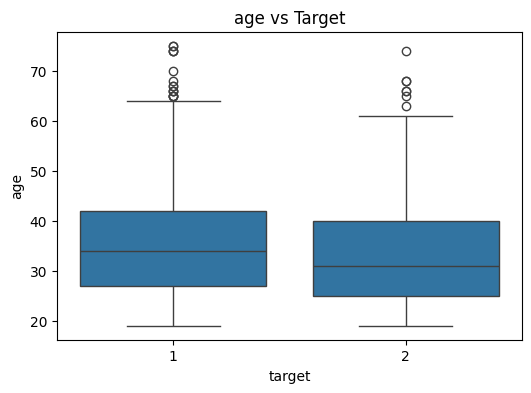

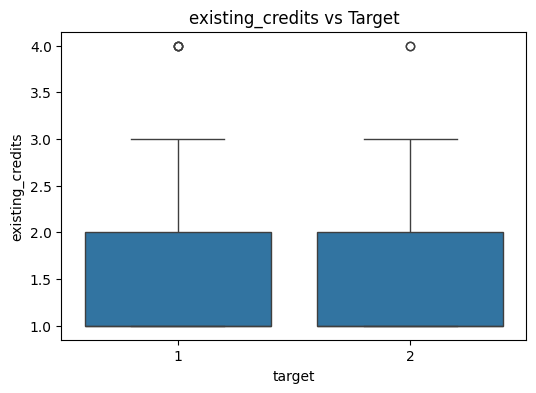

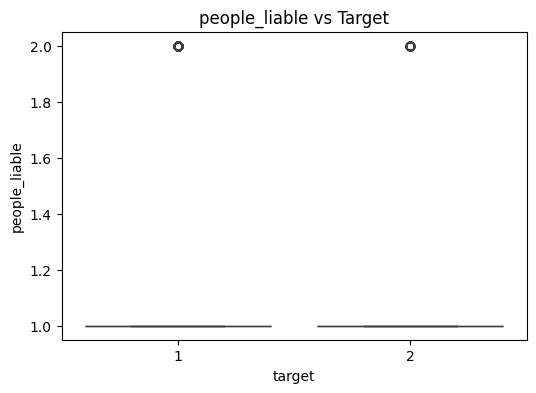

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} vs Target")
    plt.show()

The boxplots show that some numerical variables differ between the two target classes.

- `duration_months` and `credit_amount` tend to be higher for one class, suggesting they may influence credit risk.
- `age` shows slight differences between groups but not very strong.
- Variables like `installment_rate`, `residence_since`, `existing_credits`, and `people_liable` show similar distributions across both classes.

Overall, some numerical features appear more informative than others for distinguishing between the target classes.

## Categorical variables vs target

I now explore how the categorical variables are related to the target variable.

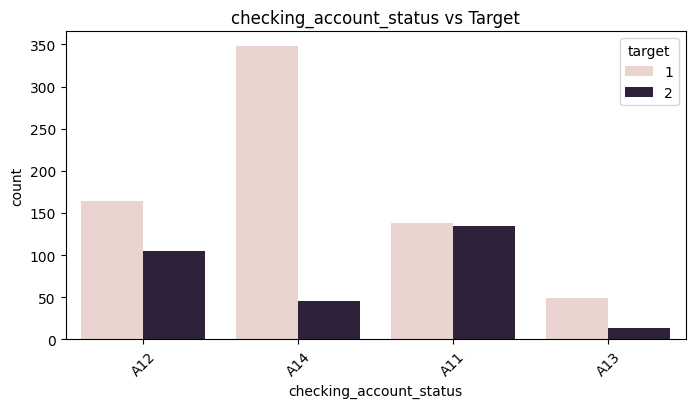

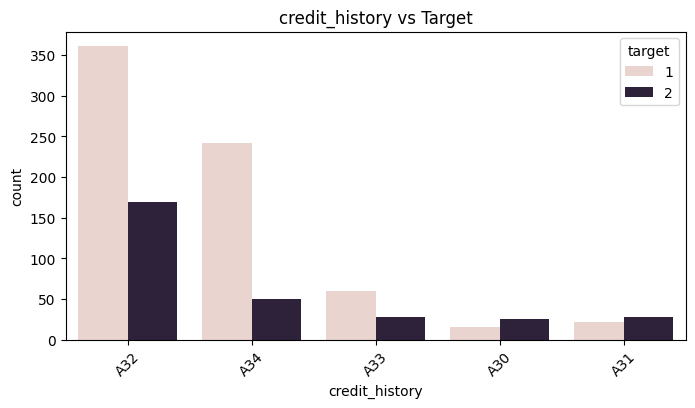

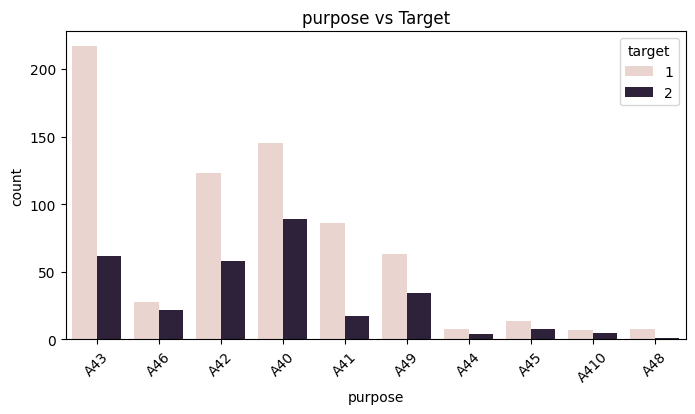

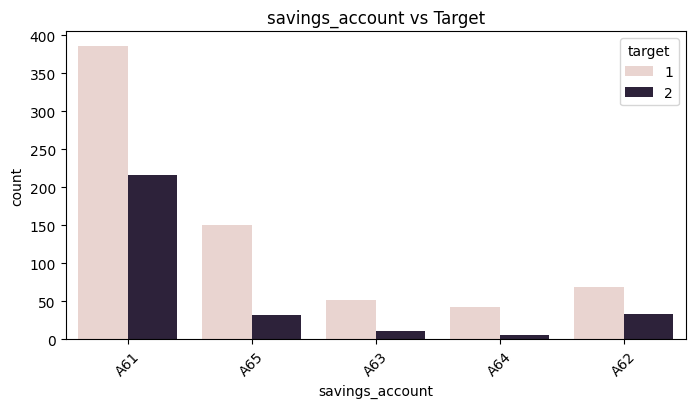

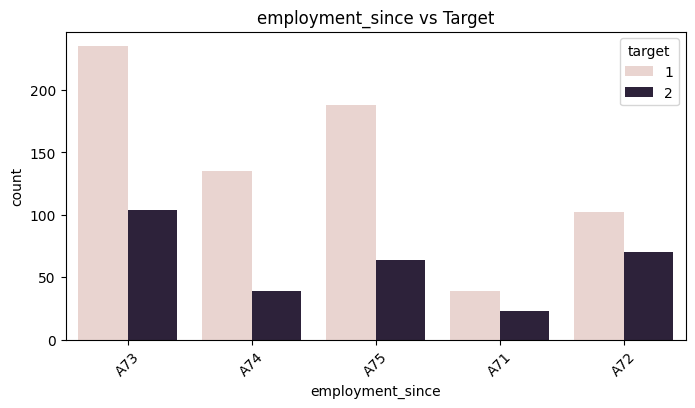

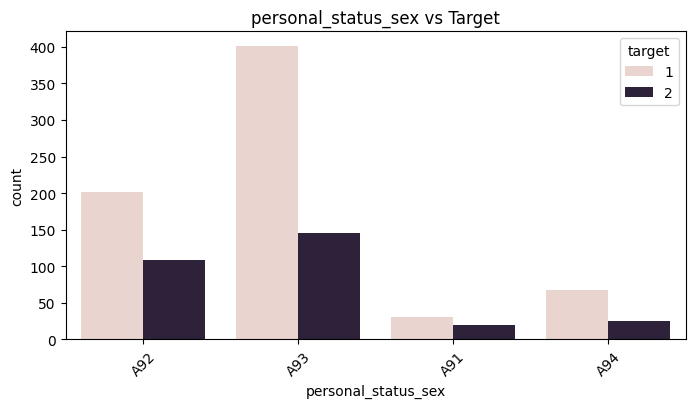

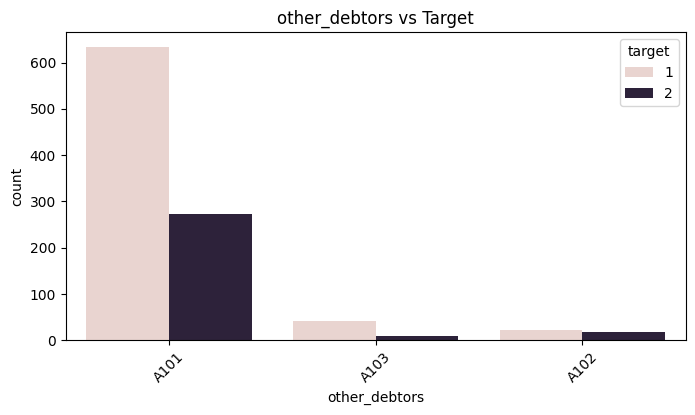

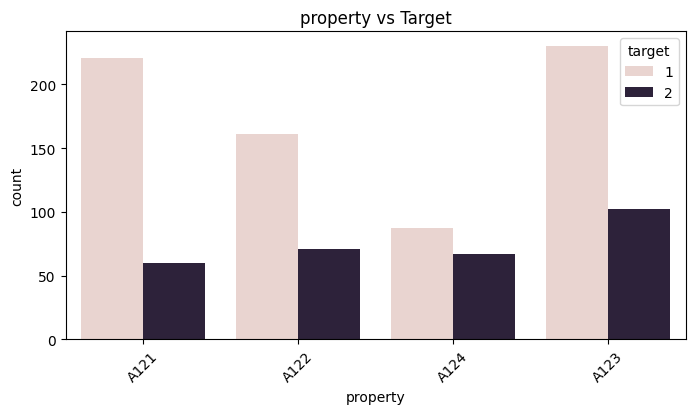

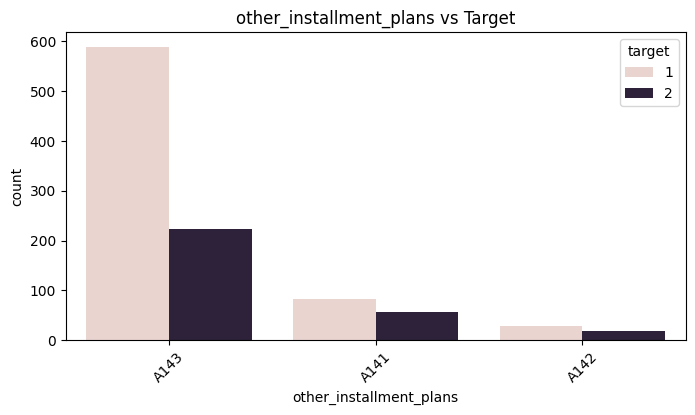

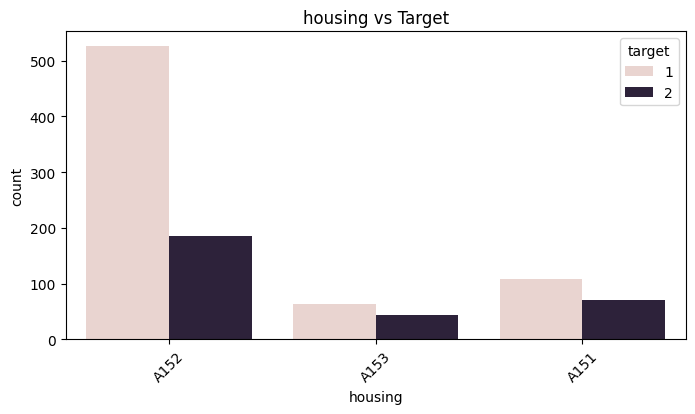

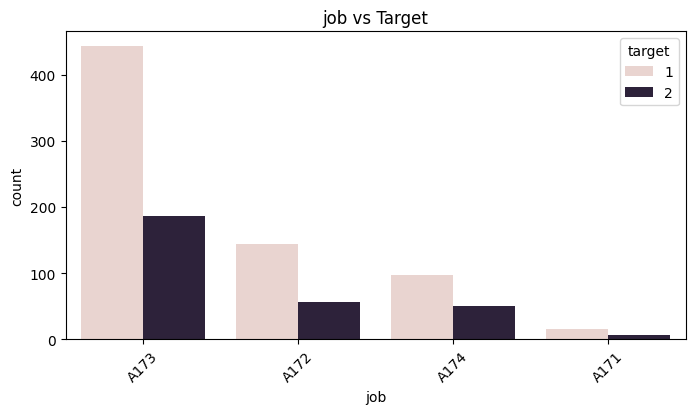

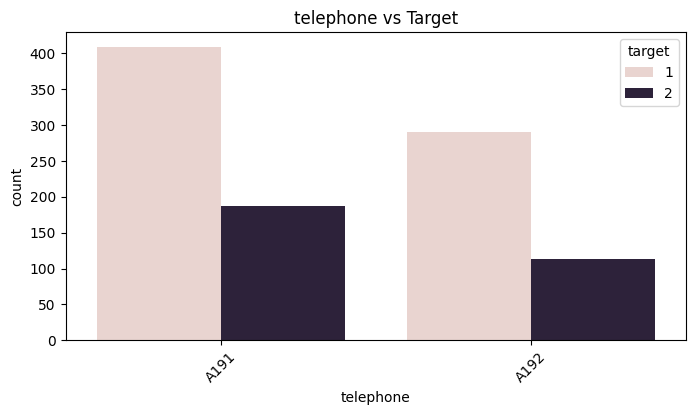

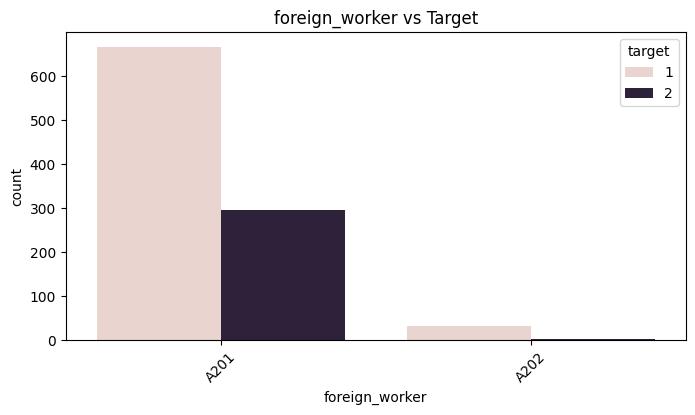

In [17]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue=target_col)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Target")
    plt.show()

The countplots show that some categorical variables have different distributions across the two target classes. For several variables, one category is much more frequent in target 1 than in target 2, which suggests that these features may be associated with credit risk. This pattern is visible in variables such as checking account status, credit history, savings account, housing, and property. At the same time, some variables show less noticeable differences between the two classes, which means they may have a weaker predictive effect. Overall, these plots suggest that categorical variables contain useful information for distinguishing between the target classes.

## Correlation analysis

To better understand the relationships between the numerical variables, we compute the correlation matrix and visualize it using a heatmap. This helps identify whether some variables are strongly related to each other and whether multicollinearity may be present in the dataset.

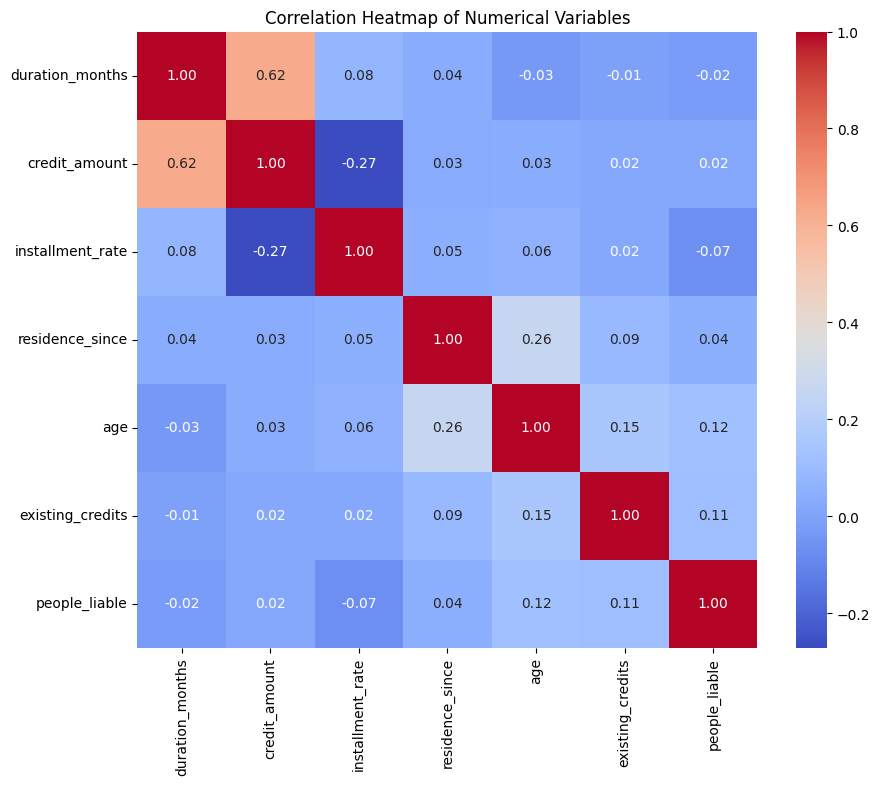

In [18]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The heatmap shows that most numerical variables have weak to moderate correlations with each other. No very strong relationships appear between the variables, which suggests that multicollinearity is limited. However, `duration_months` and `credit_amount` show a moderate positive correlation (0.62), meaning that larger credit amounts tend to be associated with longer loan durations. Apart from this relationship, the other variables are only weakly correlated. The numerical features seem to provide different information, which is useful for the modeling stage.

## Key findings

Main observations from this exploration:

- The dataset contains both numerical and categorical variables.
- The target variable is not perfectly balanced, so this should be considered during model evaluation.
- The dataset does not contain missing values or duplicated rows.
- "credit_amount" appears right-skewed and may contain extreme values.
- Some variables seem more related to the target than others.
- This exploration provides a useful foundation for the preprocessing step.